# ResearchLanka AI — NMF Trend Analysis & Forecasting (k=20, k=25)

Loads the k=20 / k=25 NMF artifacts you trained in Colab and copied to Google Drive, then:

1. Compares the two topic models (keywords, coherence/diversity/redundancy)
2. Flags emerging vs. declining research topics
3. Fits forecasting models where a topic has enough history, scored with MAE/RMSE
4. Merges in the linear SVM classification labels
5. Cross-checks the k=20 vs k=25 topic assignments against each other

**Assumption to fix first:** `/content/drive/...` is a Colab-only path — it doesn't exist outside
Colab's VM. Since you're in VS Code now, point `DRIVE_BASE` (next config cell) at wherever that
Drive folder actually lives *on this machine* — e.g. the local sync folder if you have Google Drive
for Desktop installed, or wherever you downloaded/unzipped `NMF_K20` / `NMF_K25` to.

Every loader below is defensive: missing files are printed as a warning, not a crash, so you can run
this once, see exactly what it found vs. didn't, and adjust the config cell instead of guessing blind.


In [2]:
from __future__ import annotations

import warnings
from pathlib import Path
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

try:
    from IPython.display import display
except ImportError:
    display = print  # fallback if run outside IPython

try:
    import joblib
    _JOBLIB_AVAILABLE = True
except ImportError:
    _JOBLIB_AVAILABLE = False

try:
    from statsmodels.tsa.holtwinters import ExponentialSmoothing
    _STATSMODELS_AVAILABLE = True
except ImportError:
    _STATSMODELS_AVAILABLE = False
    warnings.warn(
        "statsmodels not installed - Holt's exponential-smoothing forecast will be skipped. "
        "pip install statsmodels to enable it."
    )

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.figsize"] = (10, 5)


def rmse(y_true, y_pred) -> float:
    """Version-proof RMSE (avoids the squared= kwarg that keeps moving between sklearn versions)."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


/tmp/ipykernel_412541/485512236.py:30: UserWarning: statsmodels not installed - Holt's exponential-smoothing forecast will be skipped. pip install statsmodels to enable it.
  warnings.warn(


## Config

Change `DRIVE_BASE` below to the local path for your `ResearchLanka` Drive folder. Typical spots:

- **Windows + Google Drive for Desktop:** `G:/My Drive/ResearchLanka`
- **Mac + Google Drive for Desktop:** `~/Library/CloudStorage/GoogleDrive-<your-email>/My Drive/ResearchLanka`
- **Linux / manual download:** wherever you unzipped `NMF_K20` and `NMF_K25` to

`ARTIFACT_FILES` matches what `run_final_pipeline()` in `nmf_topic_modeling.py` writes to each
output dir. `MODEL_FILENAMES` is only used if you *also* `joblib.dump`'d the raw NMF model /
TF-IDF vectorizer / `W` matrix in Colab — if you didn't, leave those as-is and the notebook just
works from the CSVs (topic keywords, per-publication dominant topic, trend counts/shares).


In [3]:
PROJECT_DIR = Path.cwd().parent

OUTPUT_DIR = PROJECT_DIR / "notebooks/outputs"

K_DIRS = {
    20: OUTPUT_DIR / "NMF_K20/NMF_K20",
    25: OUTPUT_DIR / "NMF_K25/NMF_K25",
}

# Filenames written by run_final_pipeline() in nmf_topic_modeling.py
ARTIFACT_FILES = {
    "keywords": "nmf_topic_keywords.csv",
    "annotation": "nmf_topic_annotation_template.csv",
    "pub_topics": "nmf_publication_topics.csv",
    "trend_counts": "nmf_topic_trend_counts.csv",
    "trend_shares": "nmf_topic_trend_shares.csv",
    "k_sweep": "nmf_k_sweep_evaluation.csv",  # only exists if you ran the sweep, not fixed --k
}

# Only used if you separately pickled these in Colab. Leave alone if you didn't.
MODEL_FILENAMES = {
    "model": "nmf_model.joblib",
    "vectorizer": "tfidf_vectorizer.joblib",
    "W": "nmf_W.npy",
}

# The linear-SVM classification output that nmf_topic_modeling.py's own docstring reads from
# (common_publications_final_with_linearsvm.csv). Point this at the local copy.
CLASSIFICATION_CSV ="../data/processed/common/common_publications_final_with_linearsvm_.csv"

# Columns tried, in order, to join NMF publication-topic rows with the classification rows.
ID_COLUMN_CANDIDATES = ["id", "doi", "paper_id", "publication_id", "title"]

# Sanity check before loading anything
for k, d in K_DIRS.items():
    status = "found" if d.exists() else "NOT FOUND"
    print(f"k={k}: {d}  [{status}]")


k=20: /home/asma/Projects/researchlanka-ai/backend/notebooks/outputs/NMF_K20/NMF_K20  [found]
k=25: /home/asma/Projects/researchlanka-ai/backend/notebooks/outputs/NMF_K25/NMF_K25  [found]


In [4]:
def _find_id_column(df: pd.DataFrame, candidates=ID_COLUMN_CANDIDATES) -> Optional[str]:
    for c in candidates:
        if c in df.columns:
            return c
    return None


def load_k_artifacts(k: int, k_dir: Path) -> dict:
    """Loads whatever's present for one k. Missing files are reported, never fatal."""
    out = {"k": k, "dir": k_dir}
    if not k_dir.exists():
        print(f"[k={k}] directory not found: {k_dir}")
        return out

    for key, fname in ARTIFACT_FILES.items():
        fpath = k_dir / fname
        if fpath.exists():
            index_col = 0 if key in ("trend_counts", "trend_shares") else None
            out[key] = pd.read_csv(fpath, index_col=index_col)
        else:
            print(f"[k={k}] missing {fname}")

    if _JOBLIB_AVAILABLE:
        model_path = k_dir / MODEL_FILENAMES["model"]
        vec_path = k_dir / MODEL_FILENAMES["vectorizer"]
        if model_path.exists():
            out["model"] = joblib.load(model_path)
        if vec_path.exists():
            out["vectorizer"] = joblib.load(vec_path)

    w_path = k_dir / MODEL_FILENAMES["W"]
    if w_path.exists():
        out["W"] = np.load(w_path)

    return out


results = {k: load_k_artifacts(k, d) for k, d in K_DIRS.items()}


/tmp/ipykernel_412541/4277628002.py:19: DtypeWarning: Columns (0: source_institution_id, 1: source_datestamp, 2: openalex_id, 3: pdf_url, 4: keywords, 5: author_affiliations, 6: author_orcids, 7: sri_lankan_authors, 8: contributors, 9: institutions, 10: sri_lankan_institutions, 11: countries, 12: journal, 13: source_type, 14: issn, 15: issn_l, 16: volume, 17: issue, 18: first_page, 19: last_page, 20: article_number, 21: license, 22: license_url, 23: is_oa, 24: concepts, 25: topics, 26: primary_topic, 27: primary_field, 28: primary_subfield, 29: primary_domain, 30: funder_name, 31: funder_doi, 32: funder_identifier, 33: funder_award, 34: source_set_specs, 35: raw_identifiers, 36: citation_count_divergence_flag, 37: reference_count_divergence_flag, 38: keywords_search_text) have mixed types. Specify dtype option on import or set low_memory=False.
  out[key] = pd.read_csv(fpath, index_col=index_col)


[k=20] missing nmf_k_sweep_evaluation.csv


/tmp/ipykernel_412541/4277628002.py:19: DtypeWarning: Columns (0: source_institution_id, 1: source_datestamp, 2: openalex_id, 3: pdf_url, 4: keywords, 5: author_affiliations, 6: author_orcids, 7: sri_lankan_authors, 8: contributors, 9: institutions, 10: sri_lankan_institutions, 11: countries, 12: journal, 13: source_type, 14: issn, 15: issn_l, 16: volume, 17: issue, 18: first_page, 19: last_page, 20: article_number, 21: license, 22: license_url, 23: is_oa, 24: concepts, 25: topics, 26: primary_topic, 27: primary_field, 28: primary_subfield, 29: primary_domain, 30: funder_name, 31: funder_doi, 32: funder_identifier, 33: funder_award, 34: source_set_specs, 35: raw_identifiers, 36: citation_count_divergence_flag, 37: reference_count_divergence_flag, 38: keywords_search_text) have mixed types. Specify dtype option on import or set low_memory=False.
  out[key] = pd.read_csv(fpath, index_col=index_col)


[k=25] missing nmf_k_sweep_evaluation.csv


## 1. Topic overview — what each model actually found

Top words / auto-name per topic, plus the coherence / diversity / redundancy numbers if a
`nmf_k_sweep_evaluation.csv` is present (only written when the pipeline was run in sweep mode,
not fixed `--k`).


In [5]:
for k, res in results.items():
    print(f"\n=== k={k} ===")
    if "keywords" in res:
        display(res["keywords"][["topic_id", "topic_name", "top_words"]])
    else:
        print("(no nmf_topic_keywords.csv loaded)")

    if "k_sweep" in res:
        row = res["k_sweep"][res["k_sweep"]["k"] == k]
        if not row.empty:
            print("Sweep metrics for this k:")
            display(row[["coherence_cv", "diversity", "redundancy", "reconstruction_error"]])



=== k=20 ===


,topic_id,topic_name,top_words
0,1,different / level / conducted,"different, level, conducted, time, higher, patients, significantly, compared, years, identified, selected, showed, g..."
1,2,medicine / internal_medicine / internal,"medicine, internal medicine, internal, disease, cancer, surgery, treatment, diabetes, patients, disorders, diagnosis..."
2,3,environmental / water / environmental_science,"environmental, water, environmental science, resource, geography, agriculture, planning, environmental planning, res..."
3,4,artificial / intelligence / artificial_intelligence,"artificial, intelligence, artificial intelligence, computer, neural, computer science, neural network, network, reco..."
4,5,chemistry / organic / organic_chemistry,"chemistry, organic, organic chemistry, food, chemical, science, synthesis, food science, adsorption, biochemistry, e..."
5,6,covid / coronavirus / disease,"covid, coronavirus, disease, 2019, pandemic, outbreak, coronavirus disease, disease 2019, coronavirus disease 2019, ..."
6,7,archaeology / ancient / history,"archaeology, ancient, history, archaeological, historical, cultural, archaeology ancient, ancient environmental, arc..."
7,8,materials / composite / material,"materials, composite, material, materials science, engineering, composite material, concrete, strength, properties, ..."
8,9,biology / ecology / plant,"biology, ecology, plant, gene, genetics, species, botany, genetic, diversity, fungal, animal, zoology, biochemistry,..."
9,10,learning / machine / machine_learning,"learning, machine, machine learning, deep, deep learning, detection, prediction, classification, learning techniques..."



=== k=25 ===


,topic_id,topic_name,top_words
0,1,patients / age / hospital,"patients, age, hospital, years, group, mean, clinical, associated, conclusion, 10, patient, background, treatment, s..."
1,2,medicine / internal_medicine / internal,"medicine, internal medicine, internal, disease, cancer, surgery, disorders, diabetes, pathology, treatment, treatmen..."
2,3,environmental / water / environmental_science,"environmental, water, environmental science, resource, resource management, planning, geography, environmental plann..."
3,4,computer / computer_science / intelligence,"computer, computer science, intelligence, artificial, artificial intelligence, science, mathematics, engineering, co..."
4,5,biology / ecology / species,"biology, ecology, species, gene, genetics, genetic, plant, diversity, zoology, animal, botany, biology ecology, dna,..."
5,6,covid / coronavirus / disease,"covid, coronavirus, disease, 2019, pandemic, outbreak, coronavirus disease, disease 2019, coronavirus disease 2019, ..."
6,7,archaeology / ancient / history,"archaeology, ancient, history, archaeological, historical, archaeology ancient, cultural, ancient environmental, arc..."
7,8,materials / composite / material,"materials, composite, material, engineering, materials science, concrete, composite material, strength, properties, ..."
8,9,activity / antioxidant / food,"activity, antioxidant, food, medicinal, traditional, traditional medicine, plants, antimicrobial, food science, comp..."
9,10,machine / machine_learning / learning,"machine, machine learning, learning, prediction, algorithms, learning techniques, machine learning techniques, learn..."


## 2. Research-area trend analysis — emerging vs. declining topics

For each topic, fit a simple linear regression of `share of publications that year` against
`year`. A positive, statistically significant slope = **emerging**; negative & significant =
**declining**; otherwise **stable**. `alpha=0.10` below is a starting threshold — tighten it to
0.05 if you want a stricter "declining/emerging" call for the report.


In [6]:
def topic_trend_slopes(shares_df: pd.DataFrame) -> pd.DataFrame:
    """Linear-regression slope of each topic's year-share against year."""
    years = shares_df.index.values.astype(float)
    rows = []
    for topic in shares_df.columns:
        y = shares_df[topic].values.astype(float)
        if len(years) < 3 or np.all(np.isnan(y)):
            continue
        slope, intercept, r, p, se = stats.linregress(years, y)
        rows.append({
            "topic_name": topic,
            "slope_per_year": slope,
            "r_value": r,
            "p_value": p,
            "mean_share": float(np.nanmean(y)),
            "first_year_share": y[0],
            "last_year_share": y[-1],
        })
    return pd.DataFrame(rows).sort_values("slope_per_year", ascending=False).reset_index(drop=True)


def classify_trend(slope_df: pd.DataFrame, alpha: float = 0.10) -> pd.DataFrame:
    df = slope_df.copy()
    df["trend"] = np.where(
        (df["p_value"] < alpha) & (df["slope_per_year"] > 0), "emerging",
        np.where((df["p_value"] < alpha) & (df["slope_per_year"] < 0), "declining", "stable"),
    )
    return df


def plot_top_trends(shares_df: pd.DataFrame, slope_df: pd.DataFrame, top_n: int = 5, title_prefix: str = ""):
    top_emerging = slope_df.sort_values("slope_per_year", ascending=False).head(top_n)["topic_name"]
    top_declining = slope_df.sort_values("slope_per_year").head(top_n)["topic_name"]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    shares_df[top_emerging].plot(ax=axes[0], marker="o")
    axes[0].set_title(f"{title_prefix}Top {top_n} emerging topics")
    axes[0].set_ylabel("Share of publications")
    axes[0].legend(fontsize=8)

    shares_df[top_declining].plot(ax=axes[1], marker="o")
    axes[1].set_title(f"{title_prefix}Top {top_n} declining topics")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()



=== k=20: emerging topics ===


,topic_name,slope_per_year,r_value,p_value,mean_share,first_year_share,last_year_share,trend
0,learning / machine / machine_learning,0.006694,0.922495,0.000053,0.035249,0.009612,0.055280,emerging
1,iot / smart / security,0.005312,0.848879,0.000950,0.053299,0.038446,0.063420,emerging
2,artificial / intelligence / artificial_intelligence,0.003095,0.947555,0.000009,0.036983,0.024162,0.056612,emerging
3,archaeology / ancient / history,0.002759,0.690101,0.018760,0.032758,0.026966,0.062976,emerging



=== k=20: declining topics ===


,topic_name,slope_per_year,r_value,p_value,mean_share,first_year_share,last_year_share,trend
10,social_sciences / sciences / social_sciences_social,-0.000765,-0.628622,0.038302,0.009131,0.007209,0.003552,declining
12,dengue / mosquito / control,-0.001179,-0.907266,0.000115,0.018107,0.025898,0.014061,declining
13,materials / composite / material,-0.001474,-0.630414,0.037589,0.055698,0.056201,0.037075,declining
14,chemistry / organic / organic_chemistry,-0.001706,-0.826635,0.001703,0.049636,0.057135,0.038851,declining
15,different / level / conducted,-0.001778,-0.536978,0.088518,0.077870,0.080230,0.070599,declining
16,management / engineering / construction,-0.002083,-0.716234,0.013161,0.066499,0.085569,0.054466,declining
17,biology / ecology / plant,-0.002089,-0.661761,0.026561,0.072362,0.089174,0.080737,declining
18,economics / economic / financial,-0.003461,-0.942319,0.000014,0.056255,0.071820,0.041368,declining
19,science / political / political_science,-0.003942,-0.958399,0.000003,0.028343,0.041516,0.008732,declining


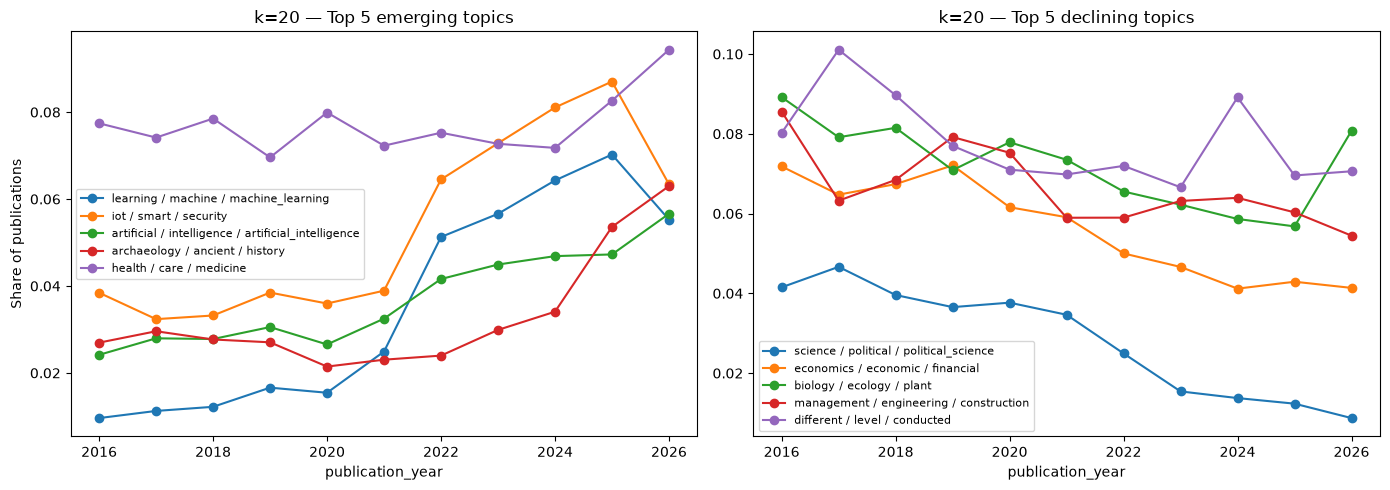


=== k=25: emerging topics ===


,topic_name,slope_per_year,r_value,p_value,mean_share,first_year_share,last_year_share,trend
0,deep / deep_learning / detection,0.006257,0.939735,0.000017,0.032394,0.009478,0.053874,emerging
1,iot / smart / monitoring,0.005304,0.891040,0.000232,0.036829,0.018823,0.049064,emerging
2,machine / machine_learning / learning,0.002948,0.885255,0.000291,0.015445,0.004005,0.022793,emerging
3,archaeology / ancient / history,0.002801,0.694093,0.017811,0.028174,0.022560,0.059276,emerging
4,patients / age / hospital,0.001869,0.598984,0.051501,0.049942,0.040716,0.065640,emerging



=== k=25: declining topics ===


,topic_name,slope_per_year,r_value,p_value,mean_share,first_year_share,last_year_share,trend
14,social_sciences / sciences / social,-0.000467,-0.677915,0.021879,0.003930,0.003337,0.001110,declining
15,activity / antioxidant / food,-0.000633,-0.601456,0.050296,0.048119,0.053397,0.043440,declining
18,dengue / mosquito / control,-0.001008,-0.837433,0.001297,0.016671,0.022694,0.013691,declining
19,chemistry / organic / organic_chemistry,-0.001326,-0.683005,0.020535,0.043466,0.046589,0.034041,declining
20,medicine / internal_medicine / internal,-0.002042,-0.818446,0.002070,0.080580,0.092778,0.072005,declining
21,economics / economic / financial,-0.002378,-0.939008,0.000018,0.033243,0.042985,0.023459,declining
22,agricultural / agriculture / soil,-0.002903,-0.957891,0.000004,0.052079,0.068082,0.038703,declining
23,political / political_science / science,-0.005053,-0.947273,0.000010,0.039404,0.057803,0.019315,declining
24,design / development / time,-0.005745,-0.730382,0.010694,0.153653,0.189828,0.113076,declining


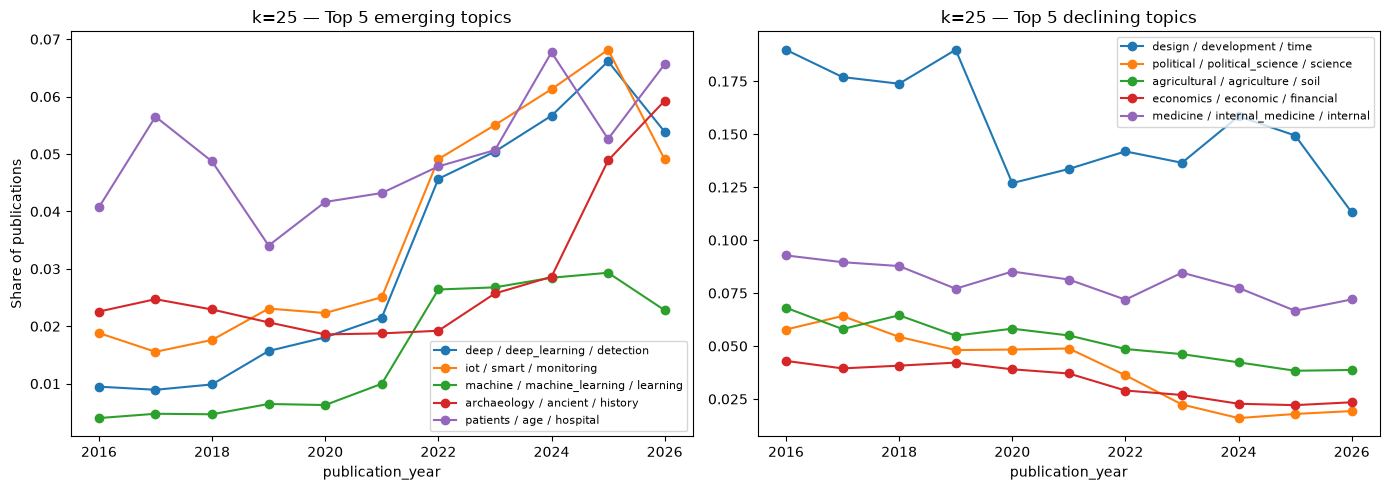

In [7]:
for k, res in results.items():
    if "trend_shares" not in res:
        print(f"[k={k}] no trend_shares loaded — skipping trend analysis.")
        continue

    slopes = classify_trend(topic_trend_slopes(res["trend_shares"]))
    res["trend_classification"] = slopes

    print(f"\n=== k={k}: emerging topics ===")
    display(slopes[slopes["trend"] == "emerging"])
    print(f"\n=== k={k}: declining topics ===")
    display(slopes[slopes["trend"] == "declining"])

    plot_top_trends(res["trend_shares"], slopes, title_prefix=f"k={k} — ")


## 3. Forecasting research-area shares (where there's enough history)

Only topics with at least `min_years` of yearly data get a forecast (default 6 — loosen this if
your corpus spans fewer years). The last `test_years` years are held out; each model is fit on
everything before that and scored against the held-out years with **MAE** and **RMSE**. Three
models are compared:

- `naive_last_value` — baseline: predict the last training year's share for every held-out year
- `linear_regression` — straight-line trend extrapolation
- `holt_linear` — Holt's linear exponential smoothing (only if `statsmodels` is installed)

Whichever has the lowest average MAE/RMSE across topics is the one worth quoting in the report.


In [8]:
def train_test_split_series(series: pd.Series, test_years: int = 2):
    if len(series) <= test_years:
        return None, None
    return series.iloc[:-test_years], series.iloc[-test_years:]


def forecast_and_score(shares_df: pd.DataFrame, test_years: int = 2, min_years: int = 6) -> pd.DataFrame:
    records = []
    for topic in shares_df.columns:
        series = shares_df[topic].dropna()
        if len(series) < min_years:
            continue
        train, test = train_test_split_series(series, test_years)
        if train is None or len(test) == 0:
            continue

        years_train = np.array(train.index, dtype=float).reshape(-1, 1)
        years_test = np.array(test.index, dtype=float).reshape(-1, 1)

        # Naive baseline
        naive_pred = np.repeat(train.values[-1], len(test))
        records.append({
            "topic_name": topic, "model": "naive_last_value",
            "mae": mean_absolute_error(test.values, naive_pred),
            "rmse": rmse(test.values, naive_pred),
        })

        # Linear regression
        lr = LinearRegression().fit(years_train, train.values)
        lr_pred = lr.predict(years_test)
        records.append({
            "topic_name": topic, "model": "linear_regression",
            "mae": mean_absolute_error(test.values, lr_pred),
            "rmse": rmse(test.values, lr_pred),
        })

        # Holt's linear exponential smoothing
        if _STATSMODELS_AVAILABLE and len(train) >= 4:
            try:
                hw_fit = ExponentialSmoothing(train.values, trend="add", seasonal=None).fit()
                hw_pred = hw_fit.forecast(len(test))
                records.append({
                    "topic_name": topic, "model": "holt_linear",
                    "mae": mean_absolute_error(test.values, hw_pred),
                    "rmse": rmse(test.values, hw_pred),
                })
            except Exception as e:
                print(f"Holt's smoothing failed for '{topic}': {e}")

    return pd.DataFrame(records)


In [9]:
for k, res in results.items():
    if "trend_shares" not in res:
        continue

    scores = forecast_and_score(res["trend_shares"], test_years=2, min_years=6)
    res["forecast_scores"] = scores

    if scores.empty:
        print(f"[k={k}] no topic had enough years of history to forecast (need >= min_years).")
        continue

    print(f"\n=== k={k}: mean MAE / RMSE by model (lower = better) ===")
    display(scores.groupby("model")[["mae", "rmse"]].mean().sort_values("mae"))

    print(f"[k={k}] best model per topic:")
    display(scores.loc[scores.groupby("topic_name")["mae"].idxmin()].sort_values("mae"))



=== k=20: mean MAE / RMSE by model (lower = better) ===


,mae,rmse
model,,
naive_last_value,0.008225,0.009000
linear_regression,0.009372,0.010189


[k=20] best model per topic:


,topic_name,model,mae,rmse
35,science / political / political_science,linear_regression,0.000159,0.000205
10,dengue / mosquito / control,naive_last_value,0.000600,0.000758
14,economics / economic / financial,naive_last_value,0.000958,0.001232
38,social_sciences / sciences / social_sciences_social,naive_last_value,0.001253,0.001276
13,different / level / conducted,linear_regression,0.001443,0.001561
29,management / engineering / construction,linear_regression,0.001870,0.001912
37,social / psychology / marketing,linear_regression,0.002136,0.002622
6,chemistry / organic / organic_chemistry,naive_last_value,0.003154,0.003156
3,artificial / intelligence / artificial_intelligence,linear_regression,0.003247,0.004143
18,environmental / water / environmental_science,naive_last_value,0.003912,0.004941



=== k=25: mean MAE / RMSE by model (lower = better) ===


,mae,rmse
model,,
naive_last_value,0.007224,0.008014
linear_regression,0.008258,0.009023


[k=25] best model per topic:


,topic_name,model,mae,rmse
49,social_sciences / sciences / social,linear_regression,0.000360,0.000497
20,economics / economic / financial,naive_last_value,0.000677,0.000677
16,dengue / mosquito / control,naive_last_value,0.000810,0.000847
3,agricultural / agriculture / soil,linear_regression,0.001603,0.001868
36,management / engineering / supply,naive_last_value,0.001607,0.001997
47,social / marketing / psychology,linear_regression,0.002505,0.002636
33,language / natural_language / processing,linear_regression,0.002545,0.002545
44,political / political_science / science,naive_last_value,0.002629,0.002717
8,chemistry / organic / organic_chemistry,naive_last_value,0.002806,0.002806
34,machine / machine_learning / learning,naive_last_value,0.003263,0.004048


## 4. Integrating the linear-SVM classification results

Merges each publication's dominant NMF topic with its SVM-predicted classification label, so you
can see which classification categories are dominated by which topics (and vice versa).

`guess_label_columns` just pattern-matches on column names (`domain`, `field`, `label`, `class`,
`category`, `svm`) — print the candidates, then hardcode `CLASSIFICATION_LABEL_COL` to whichever
one is actually your SVM prediction column before trusting the crosstab.


In [10]:


def load_classification(path: Path | str) -> Optional[pd.DataFrame]:
    path = Path(path)

    if not path.exists():
        print(f"Classification file not found: {path}")
        return None

    print(f"Loading classification file: {path}")

    return pd.read_csv(path, low_memory=False)


CLASSIFICATION_CSV = Path(CLASSIFICATION_CSV)

clf_df = load_classification(CLASSIFICATION_CSV)

if clf_df is not None:
    print(f"Classification rows: {len(clf_df):,}")
    print("Required classification columns:")

    for col in ["linearsvm_domain", "linearsvm_subfield"]:
        print(f"  {col}: {'FOUND' if col in clf_df.columns else 'NOT FOUND'}")

Classification file not found: ../data/processed/common/common_publications_final_with_linearsvm_.csv


In [11]:
def merge_with_classification(
    pub_topics: pd.DataFrame, clf_df: pd.DataFrame
) -> pd.DataFrame:

    shared_id_cols = [
        c
        for c in ID_COLUMN_CANDIDATES
        if c in pub_topics.columns and c in clf_df.columns
    ]

    if shared_id_cols:
        id_col = shared_id_cols[0]

        merged = pub_topics.merge(
            clf_df, on=id_col, suffixes=("", "_clf"), how="left", indicator=True
        )

        matched = (merged["_merge"] == "both").sum()

        print(
            f"Merged on '{id_col}' - "
            f"{matched:,}/{len(pub_topics):,} rows matched "
            f"({matched / len(pub_topics) * 100:.2f}%)"
        )

        return merged.drop(columns=["_merge"])

    # Fallback to title matching
    if "title" in pub_topics.columns and "title" in clf_df.columns:
        left = pub_topics.copy()
        right = clf_df.copy()

        left["_title_key"] = left["title"].astype(str).str.strip().str.lower()

        right["_title_key"] = right["title"].astype(str).str.strip().str.lower()

        merged = left.merge(
            right, on="_title_key", suffixes=("", "_clf"), how="left", indicator=True
        )

        matched = (merged["_merge"] == "both").sum()

        print(
            f"Merged on normalized title - "
            f"{matched:,}/{len(pub_topics):,} rows matched "
            f"({matched / len(pub_topics) * 100:.2f}%)"
        )

        return merged.drop(columns=["_title_key", "_merge"])

    print("Could not find a usable merge key (id/doi/paper_id/publication_id/title).")

    return pub_topics


In [12]:
CLASSIFICATION_LABEL_COLS = [
    "linearsvm_domain",
    "linearsvm_subfield",
]


for k, res in results.items():
    if clf_df is None:
        print(f"[k={k}] Classification data unavailable.")
        continue

    if "pub_topics" not in res:
        print(f"[k={k}] NMF publication topics unavailable.")
        continue

    # ---------------------------------------------------------
    # Merge NMF topics + Linear SVM classification
    # ---------------------------------------------------------

    merged = merge_with_classification(res["pub_topics"], clf_df)

    res["pub_topics_with_clf"] = merged

    print("\n" + "=" * 80)
    print(f"K = {k}")
    print("=" * 80)

    # ---------------------------------------------------------
    # Check required columns
    # ---------------------------------------------------------

    if "nmf_topic_name" not in merged.columns:
        print("ERROR: nmf_topic_name not found.")
        continue

    # ---------------------------------------------------------
    # Domain and Subfield analysis
    # ---------------------------------------------------------

    for label_col in CLASSIFICATION_LABEL_COLS:
        if label_col not in merged.columns:
            print(f"\nColumn not found: {label_col}")
            continue

        print("\n" + "-" * 80)
        print(f"{label_col} × NMF topic")
        print("-" * 80)

        crosstab = pd.crosstab(merged[label_col], merged["nmf_topic_name"])

        display(crosstab)

        # Save inside results for later use
        res[f"{label_col}_crosstab"] = crosstab


[k=20] Classification data unavailable.
[k=25] Classification data unavailable.


## 5. Integrating the two topic models (k=20 vs. k=25)

Two checks:

- **Coherence / diversity / redundancy side-by-side** — which k scored better on the automated
  metrics from the sweep.
- **Assignment crosstab** — for publications present in both, how often a k=20 topic maps cleanly
  onto one dominant k=25 topic vs. splitting across several (a sign k=25 is a finer-grained split
  of the same underlying area, vs. genuinely different topics).


In [13]:
def compare_k_assignments(
    res_a: dict,
    res_b: dict
) -> Optional[pd.DataFrame]:

    if "pub_topics" not in res_a or "pub_topics" not in res_b:
        print(
            "Need pub_topics loaded for both K values."
        )
        return None

    id_col = _find_id_column(res_a["pub_topics"])

    if id_col is None:
        print(
            "No usable ID column found."
        )
        return None

    if id_col not in res_b["pub_topics"].columns:
        print(
            f"ID column '{id_col}' not found in K=25."
        )
        return None

    a = res_a["pub_topics"][
        [id_col, "nmf_topic_name"]
    ].rename(
        columns={"nmf_topic_name": "topic_k20"}
    )

    b = res_b["pub_topics"][
        [id_col, "nmf_topic_name"]
    ].rename(
        columns={"nmf_topic_name": "topic_k25"}
    )

    merged = a.merge(
        b,
        on=id_col,
        how="inner"
    )

    print(
        f"{len(merged):,} publications matched "
        f"across K=20 and K=25."
    )

    return pd.crosstab(
        merged["topic_k20"],
        merged["topic_k25"]
    )

In [ ]:
if 20 in results and 25 in results:
    assignment_crosstab = compare_k_assignments(results[20], results[25])

    if assignment_crosstab is not None:
        display(assignment_crosstab)


In [ ]:
def compare_k_metrics(results: dict) -> pd.DataFrame:

    rows = []

    for k, res in results.items():
        if "k_sweep" not in res:
            continue

        row = res["k_sweep"][res["k_sweep"]["k"] == k]

        if not row.empty:
            r = row.iloc[0]

            rows.append(
                {
                    "k": k,
                    "coherence_cv": r["coherence_cv"],
                    "diversity": r["diversity"],
                    "redundancy": r["redundancy"],
                    "reconstruction_error": r["reconstruction_error"],
                }
            )

    return pd.DataFrame(rows)


metrics_comparison = compare_k_metrics(results)

if not metrics_comparison.empty:
    print("K=20 vs K=25 NMF metrics:")

    display(metrics_comparison)


In [ ]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

for k, res in results.items():
    # ---------------------------------------------------------
    # Linear SVM domain × NMF
    # ---------------------------------------------------------

    if "linearsvm_domain_crosstab" in res:
        res["linearsvm_domain_crosstab"].to_csv(
            OUTPUT_DIR / f"k{k}_linearsvm_domain_vs_nmf.csv"
        )

    # ---------------------------------------------------------
    # Linear SVM subfield × NMF
    # ---------------------------------------------------------

    if "linearsvm_subfield_crosstab" in res:
        res["linearsvm_subfield_crosstab"].to_csv(
            OUTPUT_DIR / f"k{k}_linearsvm_subfield_vs_nmf.csv"
        )


# -------------------------------------------------------------
# K20 vs K25 topic assignment comparison
# -------------------------------------------------------------

if 20 in results and 25 in results:
    ct = compare_k_assignments(results[20], results[25])

    if ct is not None:
        ct.to_csv(OUTPUT_DIR / "k20_vs_k25_assignment_crosstab.csv")


print(f"\nOutputs written to:\n{OUTPUT_DIR.resolve()}")


## 6. Export

Writes the tables you'd actually want to drop into a report or slides — trend classifications,
forecast scores, and the k=20 vs k=25 assignment crosstab — to a local `outputs/` folder next to
this notebook.


In [ ]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

for k, res in results.items():
    if "trend_classification" in res:
        res["trend_classification"].to_csv(OUTPUT_DIR / f"k{k}_trend_classification.csv", index=False)
    if "forecast_scores" in res and not res["forecast_scores"].empty:
        res["forecast_scores"].to_csv(OUTPUT_DIR / f"k{k}_forecast_scores.csv", index=False)

if 20 in results and 25 in results:
    ct = compare_k_assignments(results[20], results[25])
    if ct is not None:
        ct.to_csv(OUTPUT_DIR / "k20_vs_k25_assignment_crosstab.csv")

print(f"Wrote outputs to: {OUTPUT_DIR.resolve()}")


Need pub_topics loaded for both k's to compare assignments.
Wrote outputs to: /home/asma/Projects/researchlanka-ai/backend/notebooks/outputs


## Notes / things to double-check before quoting numbers

- `alpha=0.10` for emerging/declining is a starting point, not a settled threshold — tighten to
  0.05 if a reviewer would push back on it.
- `min_years=6` / `test_years=2` for forecasting are defaults; with a short corpus you may need to
  loosen `min_years` (fewer topics qualify) or lower `test_years` (less robust MAE/RMSE).
- `CLASSIFICATION_LABEL_COL` is auto-guessed from column names — verify it's actually the SVM
  prediction column, not a ground-truth or intermediate one, before trusting the crosstab.
- The k=20 vs k=25 assignment crosstab only tells you how publications moved between clusters, not
  which k is "more correct" — pair it with the coherence/diversity numbers and a manual look at the
  annotation template.
